In [ ]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from scipy.cluster.hierarchy import dendrogram, linkage
from pandas.plotting import parallel_coordinates, andrews_curves
df = pd.read_csv("/content/data.csv", encoding='latin1')
df['Quantity'] = pd.to_numeric(df['Quantity'])
df['UnitPrice'] = pd.to_numeric(df['UnitPrice'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['CustomerID'] = df['CustomerID'].fillna('Guest_User').astype(str)
df['Gross_Amount'] = df['Quantity'] * df['UnitPrice']
df['Order_Magnitude'] = pd.qcut(df['Gross_Amount'], q=3, labels=['Low Value', 'Medium Value', 'High Value'])
print(df[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'Gross_Amount', 'Country']].head())

  InvoiceNo                          Description  Quantity  UnitPrice  \
0    536365   WHITE HANGING HEART T-LIGHT HOLDER         6       2.55   
1    536365                  WHITE METAL LANTERN         6       3.39   
2    536365       CREAM CUPID HEARTS COAT HANGER         8       2.75   
3    536365  KNITTED UNION FLAG HOT WATER BOTTLE         6       3.39   
4    536365       RED WOOLLY HOTTIE WHITE HEART.         6       3.39   

   Gross_Amount         Country  
0         15.30  United Kingdom  
1         20.34  United Kingdom  
2         22.00  United Kingdom  
3         20.34  United Kingdom  
4         20.34  United Kingdom  


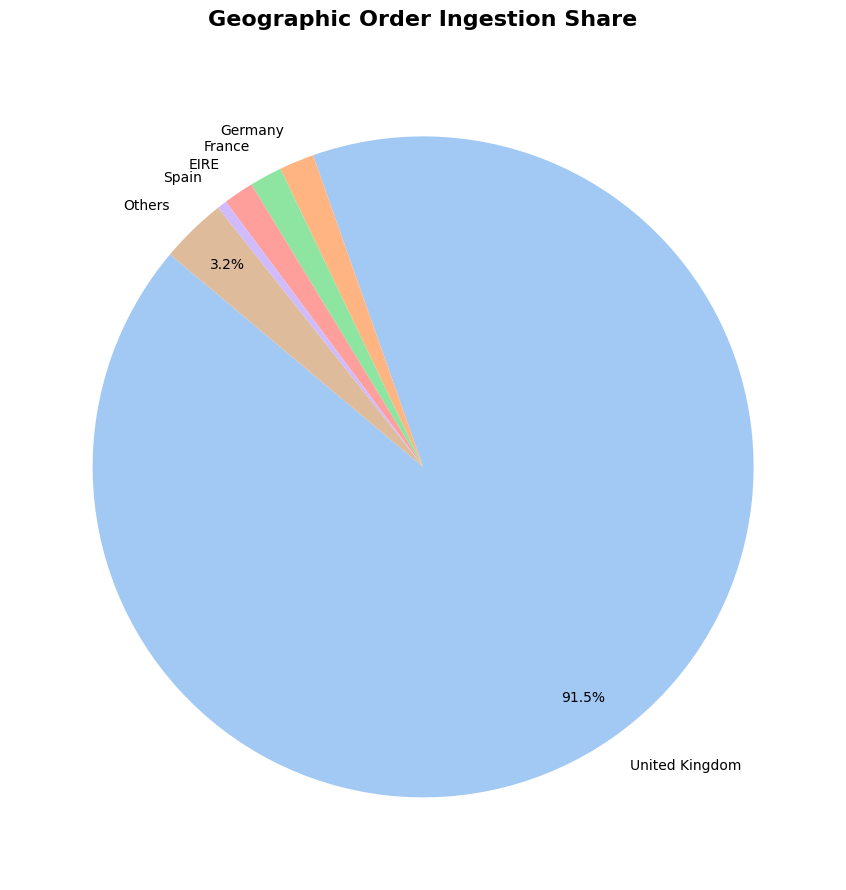

In [ ]:
def plot_pie(data_series, title="Pie Chart", top_n=5, autopct_threshold=3.0):
    if len(data_series) > top_n:
        top_data = data_series.head(top_n)
        other_sum = data_series.iloc[top_n:].sum()
        if other_sum > 0:
            data = pd.concat([top_data, pd.Series({'Others': other_sum})])
        else:
            data = top_data
    else:
        data = data_series
    labels = data.index
    sizes = data.values
    def custom_autopct(pct):
        return ('%1.1f%%' % pct) if pct > autopct_threshold else ''
    plt.figure(figsize=(9, 9))
    wedges, texts, autotexts = plt.pie(
        sizes,
        labels=labels,
        autopct=custom_autopct,
        startangle=140,
        colors=sns.color_palette('pastel'),
        pctdistance=0.85
    )
    for autotext in autotexts:
        autotext.set_color('black')
    plt.title(title, fontsize=16, weight='bold', pad=20)
    plt.tight_layout()
    plt.show()
country_distribution = df['Country'].value_counts()
plot_pie(country_distribution, title="Geographic Order Ingestion Share")

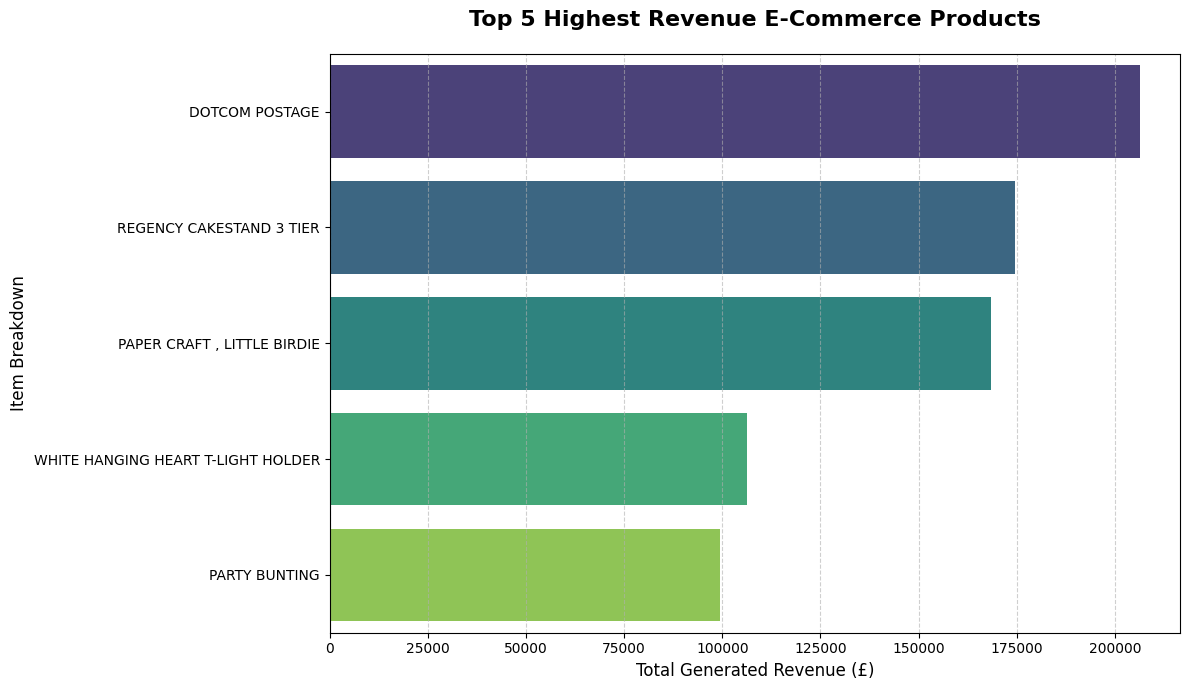

In [ ]:
def plot_bar(categories, values, title="Bar Chart"):
    plt.figure(figsize=(12, 7))
    sns.barplot(x=values, y=categories, palette='viridis', hue=categories, legend=False)
    plt.title(title, fontsize=16, weight='bold', pad=20)
    plt.xlabel("Total Generated Revenue (£)", fontsize=12)
    plt.ylabel("Item Breakdown", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
product_revenue = df.groupby('Description')['Gross_Amount'].sum().sort_values(ascending=False).head(5)
plot_bar(product_revenue.index, product_revenue.values, title="Top 5 Highest Revenue E-Commerce Products")

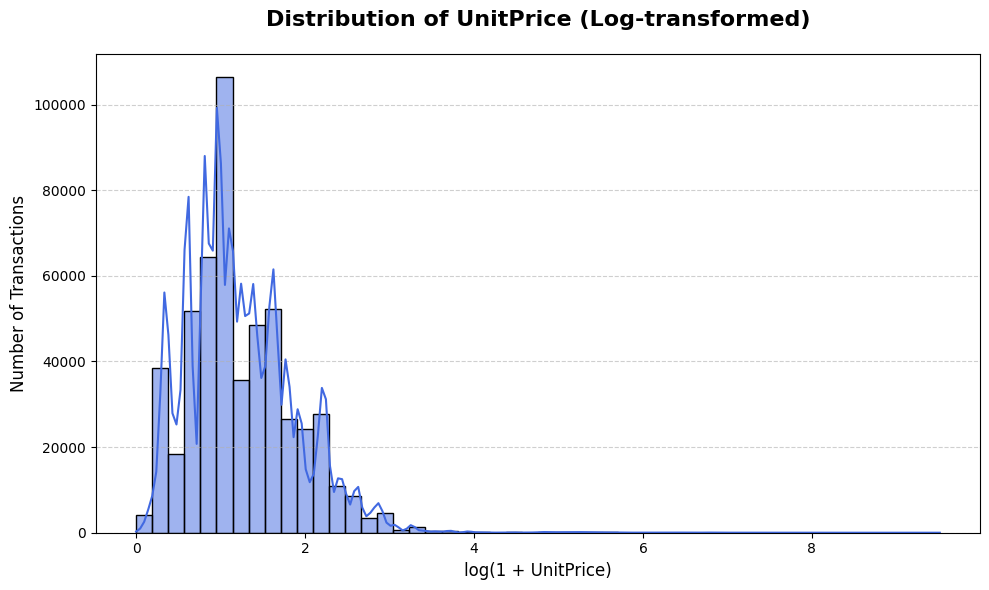

In [ ]:
def plot_histogram(df, column, log_scale=False, x_limit=None):
    plt.figure(figsize=(10, 6))
    if log_scale:
        sns.histplot(np.log1p(df[column]), kde=True, bins=50, color='royalblue', stat='count')
        plt.title(f"Distribution of {column} (Log-transformed)", fontsize=16, weight='bold', pad=20)
        plt.xlabel(f"log(1 + {column})", fontsize=12)
    else:
        sns.histplot(df[column], kde=True, bins=50, color='royalblue', stat='count')
        plt.title(f"Distribution of {column}", fontsize=16, weight='bold', pad=20)
        plt.xlabel(column, fontsize=12)
    plt.ylabel("Number of Transactions", fontsize=12)
    plt.grid(axis='y', alpha=0.6, linestyle='--')
    if x_limit and not log_scale:
        plt.xlim(0, x_limit)
    plt.tight_layout()
    plt.show()
plot_histogram(df, 'UnitPrice', log_scale=True)

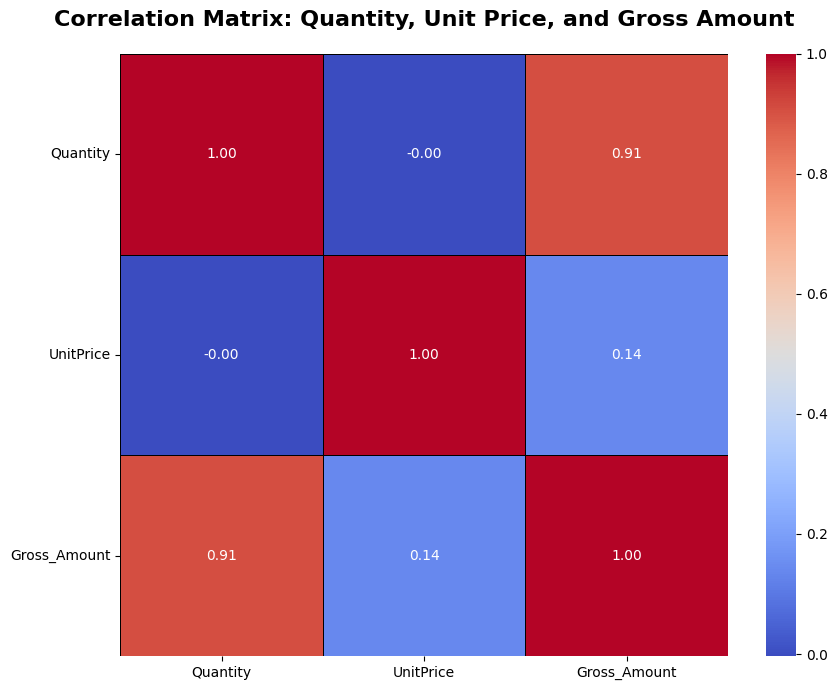

In [ ]:
def heatmap(df, annot=True, cmap='coolwarm'):
    plt.figure(figsize=(9, 7))
    numeric_matrix = df[['Quantity', 'UnitPrice', 'Gross_Amount']].corr()
    sns.heatmap(numeric_matrix, annot=annot, cmap=cmap, fmt=".2f", linewidths=0.7, linecolor='black')
    plt.title("Correlation Matrix: Quantity, Unit Price, and Gross Amount", fontsize=16, weight='bold', pad=20)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10, rotation=0)
    plt.tight_layout()
    plt.show()
heatmap(df)

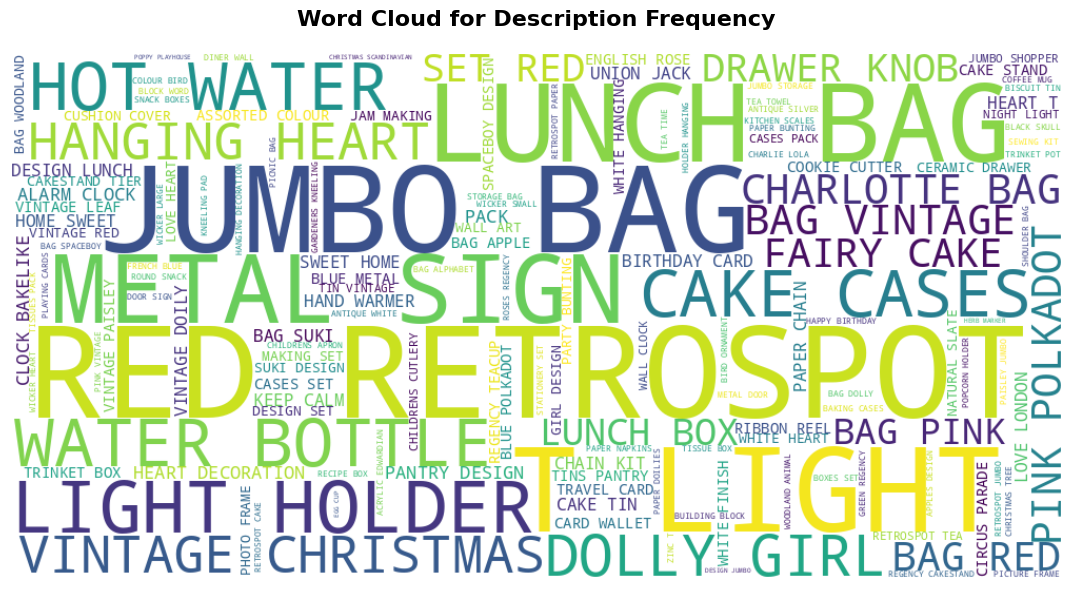

In [ ]:
def plot_wordcloud(df, text_column):
    text_corpus = " ".join(df[text_column].astype(str).dropna())
    wordcloud = WordCloud(
        width=1000, height=500,
        background_color='white',
        colormap='viridis',
        max_words=150,
        contour_width=3,
        contour_color='steelblue').generate(text_corpus)
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {text_column} Frequency", fontsize=16, weight='bold', pad=20)
    plt.tight_layout()
    plt.show()
plot_wordcloud(df, 'Description')

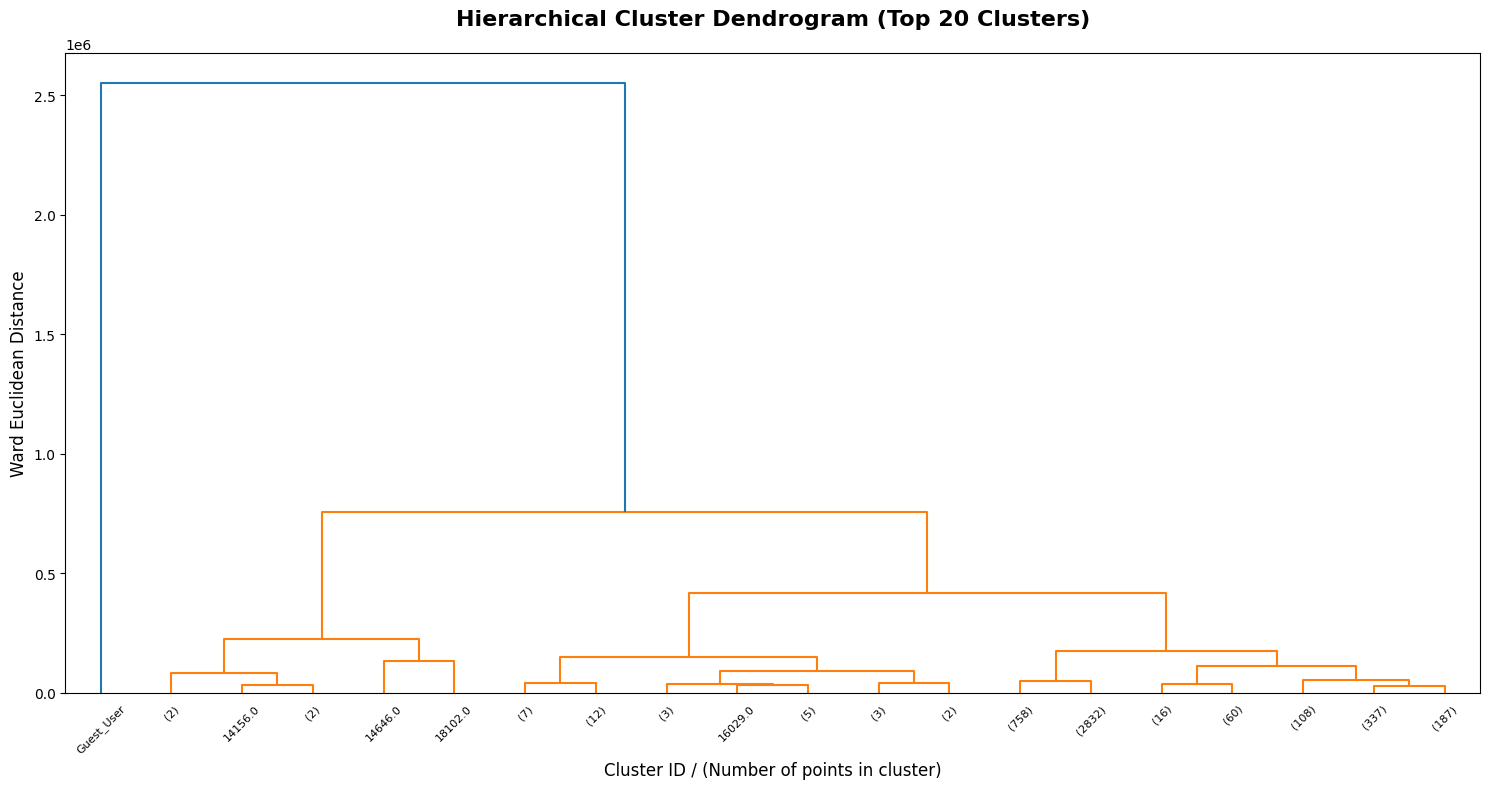

In [ ]:
def plot_dendrograms(df, p=20, truncate_mode='lastp'):
    customer_profiles = df.groupby('CustomerID')[['Quantity', 'Gross_Amount']].sum().reset_index()
    features = customer_profiles[['Quantity', 'Gross_Amount']].values
    linked_matrix = linkage(features, method='ward')
    plt.figure(figsize=(15, 8))
    dendrogram(
        linked_matrix,
        labels=customer_profiles['CustomerID'].values,
        orientation='top',
        leaf_rotation=45,
        leaf_font_size=8,
        truncate_mode=truncate_mode,
        p=p,
        show_leaf_counts=True
    )
    plt.title(f"Hierarchical Cluster Dendrogram (Top {p} Clusters)", fontsize=16, weight='bold', pad=20)
    plt.xlabel("Cluster ID / (Number of points in cluster)", fontsize=12)
    plt.ylabel("Ward Euclidean Distance", fontsize=12)
    plt.tight_layout()
    plt.show()
plot_dendrograms(df, p=20)

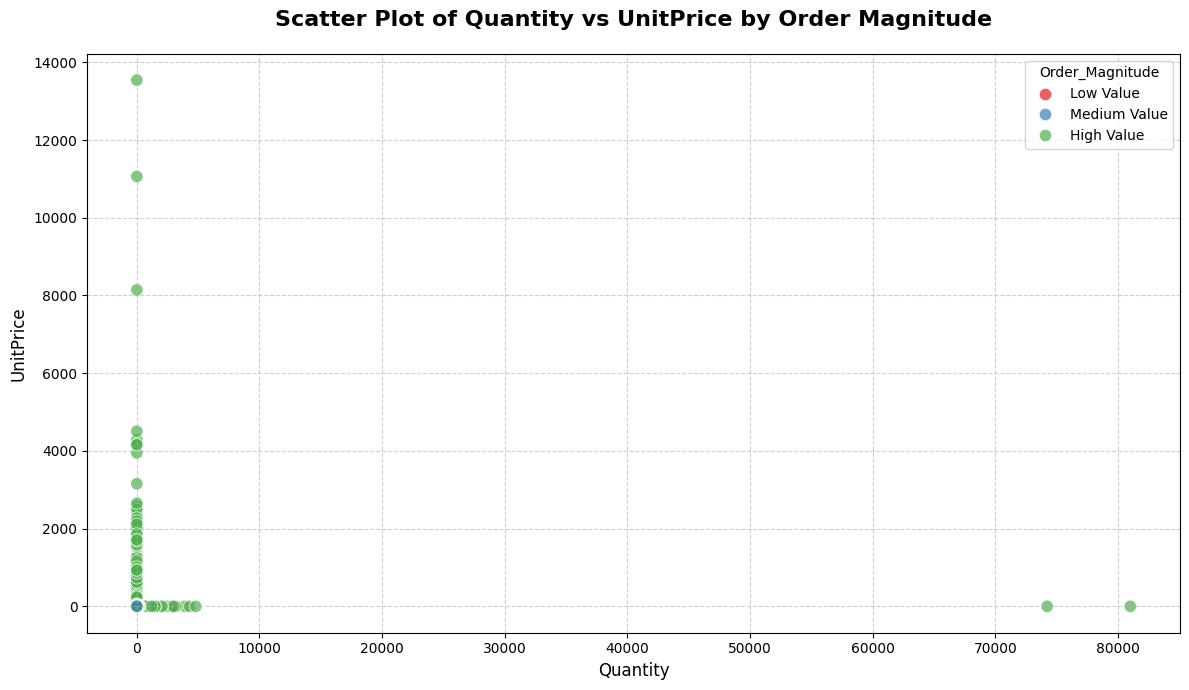

In [ ]:
def scatter_plot(df, x, y, x_limit=None, y_limit=None):
    plt.figure(figsize=(12, 7))
    sns.scatterplot(data=df, x=x, y=y, hue='Order_Magnitude', palette='Set1', s=80, alpha=0.7)
    plt.title(f"Scatter Plot of {x} vs {y} by Order Magnitude", fontsize=16, weight='bold', pad=20)
    plt.xlabel(x, fontsize=12)
    plt.ylabel(y, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    if x_limit:
        plt.xlim(0, x_limit)
    if y_limit:
        plt.ylim(0, y_limit)
    plt.tight_layout()
    plt.show()
scatter_plot(df, 'Quantity', 'UnitPrice')

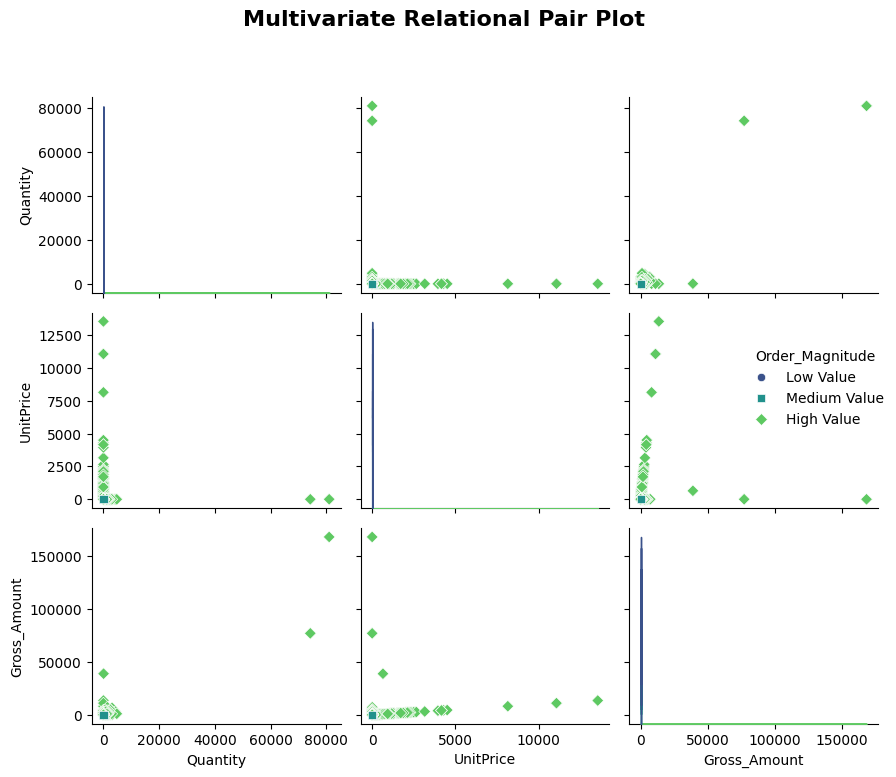

In [ ]:
def plot_pairplots(df):
    plot_cols = ['Quantity', 'UnitPrice', 'Gross_Amount']
    g = sns.pairplot(
        df[plot_cols + ['Order_Magnitude']],
        hue='Order_Magnitude',
        palette='viridis',
        diag_kind='kde',
        markers=["o", "s", "D"],
        height=2.5
    )
    g.fig.suptitle("Multivariate Relational Pair Plot", y=1.03, fontsize=16, weight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
plot_pairplots(df)

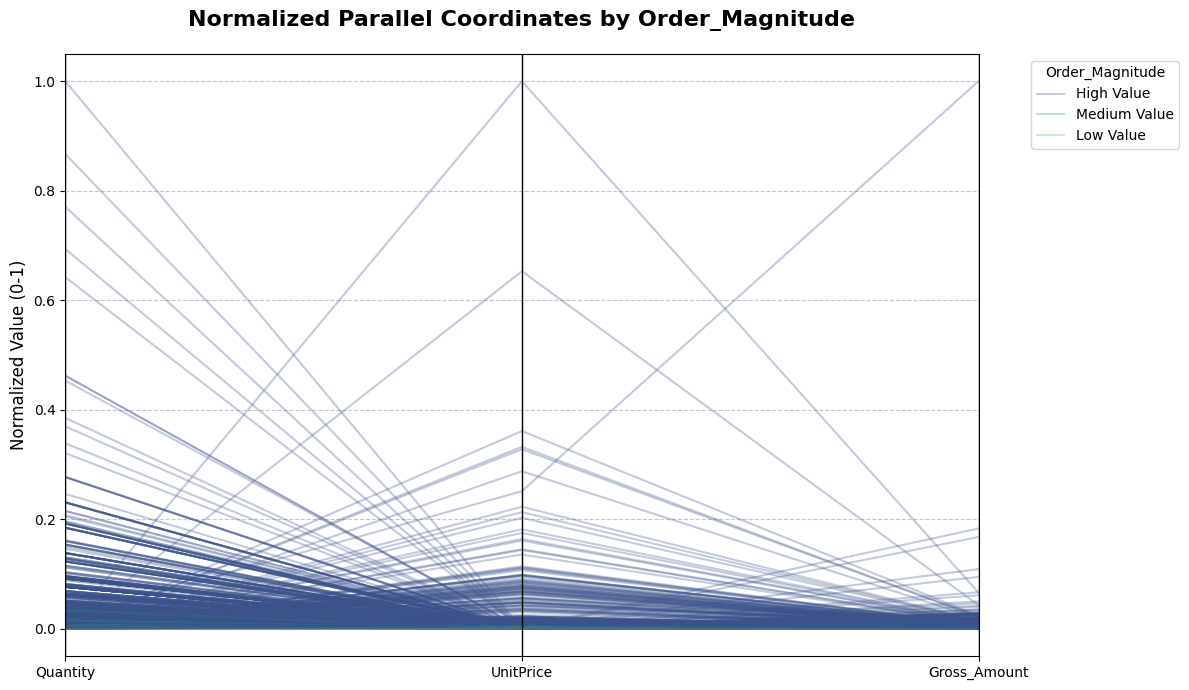

In [ ]:
def plot_parallel_coordinates(df, class_column, sample_frac=0.1, alpha=0.3):
    plt.figure(figsize=(12, 7))
    if len(df) > 5000:
        subset_df = df.sample(frac=sample_frac, random_state=42)
    else:
        subset_df = df.copy()
    subset = subset_df[['Quantity', 'UnitPrice', 'Gross_Amount', class_column]].copy()
    for col in ['Quantity', 'UnitPrice', 'Gross_Amount']:
        min_val = subset[col].min()
        max_val = subset[col].max()
        if max_val > min_val:
            subset[col] = (subset[col] - min_val) / (max_val - min_val)
        else:
            subset[col] = 0.5
    colors = sns.color_palette('viridis', n_colors=len(subset[class_column].unique()))
    parallel_coordinates(subset, class_column, color=colors, alpha=alpha)
    plt.title(f"Normalized Parallel Coordinates by {class_column}", fontsize=16, weight='bold', pad=20)
    plt.ylabel("Normalized Value (0-1)", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=0)
    plt.legend(title=class_column, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
plot_parallel_coordinates(df, 'Order_Magnitude')

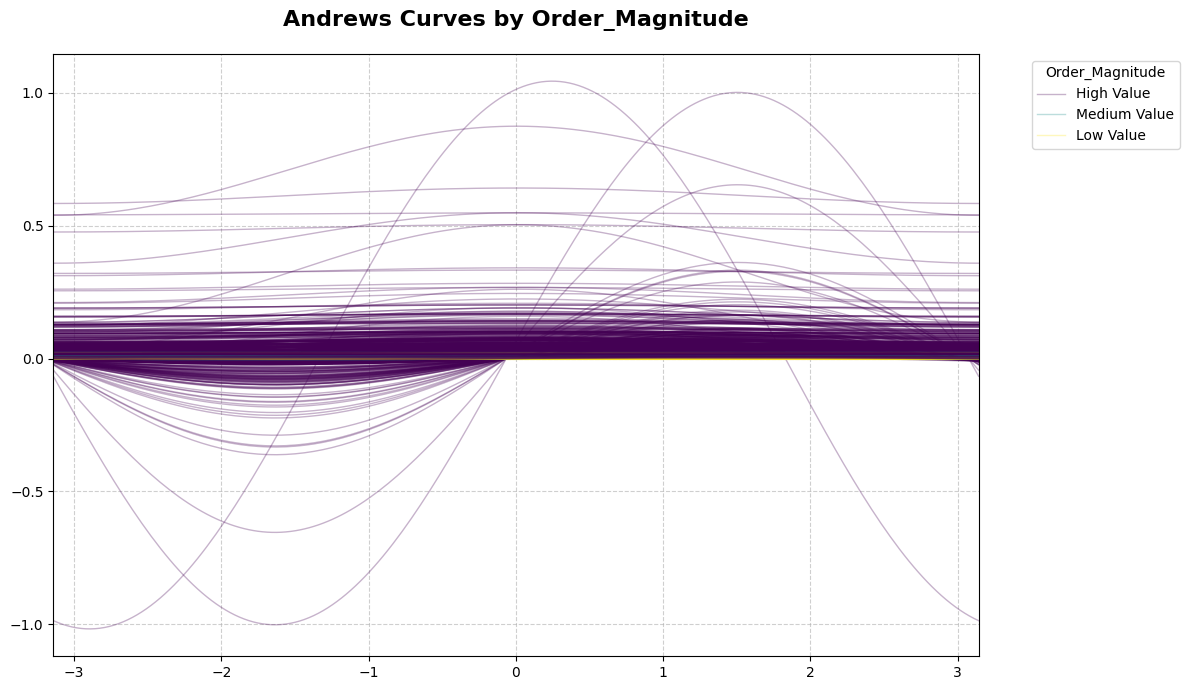

In [ ]:
def plot_andrews_curves(df, class_column, sample_frac=0.1, alpha=0.3):
    plt.figure(figsize=(12, 7))
    if len(df) > 5000:
        subset = df.sample(frac=sample_frac, random_state=42)
    else:
        subset = df.copy()
    subset = subset[['Quantity', 'UnitPrice', 'Gross_Amount', class_column]].copy()
    for col in ['Quantity', 'UnitPrice', 'Gross_Amount']:
        min_val = subset[col].min()
        max_val = subset[col].max()
        if max_val > min_val:
            subset[col] = (subset[col] - min_val) / (max_val - min_val)
        else:
            subset[col] = 0
    andrews_curves(subset, class_column, colormap='viridis', linewidth=1, alpha=alpha)
    plt.title(f"Andrews Curves by {class_column}", fontsize=16, weight='bold', pad=20)
    plt.grid(True, alpha=0.6, linestyle='--')
    plt.legend(title=class_column, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
plot_andrews_curves(df, 'Order_Magnitude')

In [ ]:
def plot_choropleth(df):
    geo_df = df.groupby('Country')['Gross_Amount'].sum().reset_index()
    geo_df.columns = ['Country_Name', 'Total_Sales_Value']
    fig = px.choropleth(
        geo_df,
        locations="Country_Name",
        locationmode="country names",
        color="Total_Sales_Value",
        hover_name="Country_Name",
        color_continuous_scale=px.colors.sequential.Plasma,
        title="Interactive Global Choropleth Sales Distribution Map")
    fig.update_layout(coloraxis_colorbar=dict(title="Revenue (£)"))
    fig.show()
plot_choropleth(df)